<a href="https://colab.research.google.com/github/Fatou-Kine3/github_task/blob/main/logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
## Problem 1 — Hypothesis Function

The logistic regression hypothesis converts the linear score into a
probability using the sigmoid function.

The output is always between 0 and 1.

In [1]:
def _sigmoid(self, z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def _hypothesis(self, X):
    z = X @ self.theta
    return self._sigmoid(z)

In [3]:
import numpy as np


class ScratchLogisticRegression:
    """Scratch implementation of binary logistic regression."""

    def __init__(self, num_iter, lr, no_bias, verbose, lam):
        self.num_iter = num_iter
        self.lr = lr
        self.no_bias = no_bias
        self.verbose = verbose
        self.lam = lam
        self.theta = None
        self.loss = np.zeros(num_iter)
        self.val_loss = np.full(num_iter, np.nan)

    def _sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def _hypothesis(self, X):
        z = X @ self.theta
        return self._sigmoid(z)

    def fit(self, X, y, X_val=None, y_val=None):
        pass

    def predict(self, X):
        pass

    def predict_proba(self, X):
        pass

In [4]:
model = ScratchLogisticRegression(
    num_iter=100,
    lr=0.01,
    no_bias=False,
    verbose=False,
    lam=0.0
)

model.theta = np.array([1.0, -1.0])

X_test = np.array([
    [1.0, 2.0],
    [2.0, 1.0],
    [0.0, 0.0]
])

probabilities = model._hypothesis(X_test)

print(probabilities)

[0.26894142 0.73105858 0.5       ]


In [ ]:
# Problem 2 — Gradient Descent

In [5]:
def _gradient_descent(self, X, y):
    """Update model parameters using gradient descent."""

    m = X.shape[0]

    # Predicted probabilities
    y_pred = self._hypothesis(X)

    # Gradient of the loss
    gradient = (X.T @ (y_pred - y)) / m

    # L2 regularization
    if self.no_bias:
        gradient += self.lam * self.theta
    else:
        # Do not regularize the intercept
        gradient[1:] += self.lam * self.theta[1:]

    # Update parameters
    self.theta -= self.lr * gradient

In [6]:
def fit(self, X, y, X_val=None, y_val=None):

    # Add intercept
    if not self.no_bias:
        X = np.c_[np.ones(X.shape[0]), X]

    # Initialize parameters
    self.theta = np.zeros(X.shape[1])

    # Gradient descent
    for i in range(self.num_iter):
        self._gradient_descent(X, y)

In [7]:
X_test = np.array([
    [1.0, 2.0],
    [2.0, 1.0],
    [3.0, 3.0],
    [4.0, 2.0]
])

y_test = np.array([0, 0, 1, 1])

model = ScratchLogisticRegression(
    num_iter=100,
    lr=0.01,
    no_bias=False,
    verbose=False,
    lam=0.1
)

model.fit(X_test, y_test)

print("Learned parameters:")
print(model.theta)

Learned parameters:
None


In [11]:
import numpy as np


class ScratchLogisticRegression:

    def __init__(self, num_iter, lr, no_bias, verbose, lam):
        self.num_iter = num_iter
        self.lr = lr
        self.no_bias = no_bias
        self.verbose = verbose
        self.lam = lam
        self.theta = None
        self.loss = np.zeros(num_iter)
        self.val_loss = np.full(num_iter, np.nan)

    def _sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def _hypothesis(self, X):
        z = X @ self.theta
        return self._sigmoid(z)

    def _gradient_descent(self, X, y):

        m = X.shape[0]

        y_pred = self._hypothesis(X)

        gradient = (X.T @ (y_pred - y)) / m

        if self.no_bias:
            gradient += self.lam * self.theta
        else:
            gradient[1:] += self.lam * self.theta[1:]

        self.theta -= self.lr * gradient

    def fit(self, X, y, X_val=None, y_val=None):

        if not self.no_bias:
            X = np.c_[np.ones(X.shape[0]), X]

        self.theta = np.zeros(X.shape[1])

        for i in range(self.num_iter):
            self._gradient_descent(X, y)

    def predict(self, X):
        pass

    def predict_proba(self, X):
        pass

In [12]:
model = ScratchLogisticRegression(
    num_iter=100,
    lr=0.01,
    no_bias=False,
    verbose=False,
    lam=0.1
)

In [13]:
X_test = np.array([
    [1.0, 2.0],
    [2.0, 1.0],
    [3.0, 3.0],
    [4.0, 2.0]
])

y_test = np.array([0, 0, 1, 1])

model.fit(X_test, y_test)

In [14]:
print("Learned parameters:")
print(model.theta)

Learned parameters:
[-0.09331739  0.21118839  0.04608286]


In [ ]:
### Result

The gradient descent algorithm updates the model parameters
iteratively.

The intercept is not regularized, while the feature weights are
regularized using L2 regularization.

The learned `theta` values confirm that the parameters were updated
during training.

In [ ]:
# Problem 3 — Prediction

In [15]:
def predict_proba(self, X):
    """Return the probability of class 1."""

    if not self.no_bias:
        X = np.c_[np.ones(X.shape[0]), X]

    return self._hypothesis(X)

In [16]:
def predict(self, X):
    """Predict binary class labels."""

    probabilities = self.predict_proba(X)

    return (probabilities >= 0.5).astype(int)

In [17]:
class ScratchLogisticRegression:

    def __init__(self, num_iter, lr, no_bias, verbose, lam):
        self.num_iter = num_iter
        self.lr = lr
        self.no_bias = no_bias
        self.verbose = verbose
        self.lam = lam
        self.theta = None
        self.loss = np.zeros(num_iter)
        self.val_loss = np.full(num_iter, np.nan)

    def _sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def _hypothesis(self, X):
        z = X @ self.theta
        return self._sigmoid(z)

    def _gradient_descent(self, X, y):
        m = X.shape[0]

        y_pred = self._hypothesis(X)

        gradient = (X.T @ (y_pred - y)) / m

        if self.no_bias:
            gradient += self.lam * self.theta
        else:
            gradient[1:] += self.lam * self.theta[1:]

        self.theta -= self.lr * gradient

    def fit(self, X, y, X_val=None, y_val=None):

        if not self.no_bias:
            X = np.c_[np.ones(X.shape[0]), X]

        self.theta = np.zeros(X.shape[1])

        for i in range(self.num_iter):
            self._gradient_descent(X, y)

    def predict_proba(self, X):

        if not self.no_bias:
            X = np.c_[np.ones(X.shape[0]), X]

        return self._hypothesis(X)

    def predict(self, X):

        probabilities = self.predict_proba(X)

        return (probabilities >= 0.5).astype(int)

In [18]:
probabilities = model.predict_proba(X_test)
predictions = model.predict(X_test)

print("Predicted probabilities:")
print(probabilities)

print("\nPredicted labels:")
print(predictions)

Predicted probabilities:
None

Predicted labels:
None


In [19]:
import numpy as np


class ScratchLogisticRegression:

    def __init__(self, num_iter, lr, no_bias, verbose, lam):
        self.num_iter = num_iter
        self.lr = lr
        self.no_bias = no_bias
        self.verbose = verbose
        self.lam = lam
        self.theta = None
        self.loss = np.zeros(num_iter)
        self.val_loss = np.full(num_iter, np.nan)

    def _sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def _hypothesis(self, X):
        z = X @ self.theta
        return self._sigmoid(z)

    def _gradient_descent(self, X, y):
        m = X.shape[0]

        y_pred = self._hypothesis(X)

        gradient = (X.T @ (y_pred - y)) / m

        if self.no_bias:
            gradient += self.lam * self.theta
        else:
            gradient[1:] += self.lam * self.theta[1:]

        self.theta -= self.lr * gradient

    def fit(self, X, y, X_val=None, y_val=None):

        if not self.no_bias:
            X = np.c_[np.ones(X.shape[0]), X]

        self.theta = np.zeros(X.shape[1])

        for i in range(self.num_iter):
            self._gradient_descent(X, y)

    def predict_proba(self, X):

        if not self.no_bias:
            X = np.c_[np.ones(X.shape[0]), X]

        return self._hypothesis(X)

    def predict(self, X):

        probabilities = self.predict_proba(X)

        return (probabilities >= 0.5).astype(int)

In [20]:
model = ScratchLogisticRegression(
    num_iter=100,
    lr=0.01,
    no_bias=False,
    verbose=False,
    lam=0.1
)

model.fit(X_test, y_test)

In [21]:
probabilities = model.predict_proba(X_test)
predictions = model.predict(X_test)

print("Predicted probabilities:")
print(probabilities)

print("\nPredicted labels:")
print(predictions)

Predicted probabilities:
[0.55231699 0.59270094 0.66340302 0.69922327]

Predicted labels:
[1 1 1 1]


In [ ]:
# Problem4  — Objective function

In [22]:
def _compute_loss(self, X, y):
    """Compute binary cross-entropy loss with L2 regularization."""

    m = X.shape[0]

    # Predicted probabilities
    y_pred = self._hypothesis(X)

    # Avoid log(0) and log(1)
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    # Binary cross-entropy
    loss = -np.mean(
        y * np.log(y_pred) +
        (1 - y) * np.log(1 - y_pred)
    )

    # L2 regularization
    if self.no_bias:
        reg = (self.lam / (2 * m)) * np.sum(self.theta ** 2)
    else:
        reg = (self.lam / (2 * m)) * np.sum(self.theta[1:] ** 2)

    return loss + reg

In [23]:
def fit(self, X, y, X_val=None, y_val=None):

    # Add intercept
    if not self.no_bias:
        X = np.c_[np.ones(X.shape[0]), X]

    # Add intercept to validation data
    if X_val is not None and not self.no_bias:
        X_val = np.c_[np.ones(X_val.shape[0]), X_val]

    # Initialize parameters
    self.theta = np.zeros(X.shape[1])

    # Gradient descent
    for i in range(self.num_iter):

        # Update parameters
        self._gradient_descent(X, y)

        # Training loss
        self.loss[i] = self._compute_loss(X, y)

        # Validation loss
        if X_val is not None and y_val is not None:
            self.val_loss[i] = self._compute_loss(X_val, y_val)

        if self.verbose:
            print(
                f"Iteration {i + 1}/{self.num_iter}, "
                f"Loss: {self.loss[i]:.6f}"
            )

In [30]:
X_test_bias = np.c_[np.ones(X_test.shape[0]), X_test]

print("Theta:")
print(model.theta)

print("\nHypothesis:")
print(model._hypothesis(X_test_bias))

print("\nLoss:")
print(model._compute_loss(X_test_bias, y_test))

Theta:
[-0.09331739  0.21118839  0.04608286]

Hypothesis:
[0.55231699 0.59270094 0.66340302 0.69922327]

Loss:


AttributeError: 'ScratchLogisticRegression' object has no attribute '_compute_loss'

In [31]:
def _compute_loss(self, X, y):
    """Compute binary cross-entropy loss with L2 regularization."""

    m = X.shape[0]

    # Predicted probabilities
    y_pred = self._hypothesis(X)

    # Avoid log(0)
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    # Binary cross-entropy
    cross_entropy = -np.mean(
        y * np.log(y_pred)
        + (1 - y) * np.log(1 - y_pred)
    )

    # L2 regularization
    if self.no_bias:
        regularization = (
            self.lam / (2 * m)
        ) * np.sum(self.theta ** 2)
    else:
        # Exclude the intercept
        regularization = (
            self.lam / (2 * m)
        ) * np.sum(self.theta[1:] ** 2)

    return cross_entropy + regularization

In [32]:
model = ScratchLogisticRegression(
    num_iter=100,
    lr=0.01,
    no_bias=False,
    verbose=False,
    lam=0.1
)

model.fit(X_test, y_test)

In [5]:
import numpy as np


class ScratchLogisticRegression:

    def __init__(self, num_iter, lr, no_bias, verbose, lam):
        self.num_iter = num_iter
        self.lr = lr
        self.no_bias = no_bias
        self.verbose = verbose
        self.lam = lam
        self.theta = None
        self.loss = np.zeros(num_iter)
        self.val_loss = np.full(num_iter, np.nan)

    def _sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def _hypothesis(self, X):
        z = X @ self.theta
        return self._sigmoid(z)

    def _gradient_descent(self, X, y):
        m = X.shape[0]

        y_pred = self._hypothesis(X)

        gradient = (X.T @ (y_pred - y)) / m

        if self.no_bias:
            gradient += self.lam * self.theta
        else:
            gradient[1:] += self.lam * self.theta[1:]

        self.theta -= self.lr * gradient

    def _compute_loss(self, X, y):
        m = X.shape[0]

        y_pred = self._hypothesis(X)

        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

        cross_entropy = -np.mean(
            y * np.log(y_pred)
            + (1 - y) * np.log(1 - y_pred)
        )

        if self.no_bias:
            regularization = (
                self.lam / (2 * m)
            ) * np.sum(self.theta ** 2)
        else:
            regularization = (
                self.lam / (2 * m)
            ) * np.sum(self.theta[1:] ** 2)

        return cross_entropy + regularization

    def fit(self, X, y, X_val=None, y_val=None):

        if not self.no_bias:
            X = np.c_[np.ones(X.shape[0]), X]

        if X_val is not None and not self.no_bias:
            X_val = np.c_[np.ones(X_val.shape[0]), X_val]

        self.theta = np.zeros(X.shape[1])

        for i in range(self.num_iter):

            self._gradient_descent(X, y)

            self.loss[i] = self._compute_loss(X, y)

            if X_val is not None and y_val is not None:
                self.val_loss[i] = self._compute_loss(X_val, y_val)

    def predict_proba(self, X):

        if not self.no_bias:
            X = np.c_[np.ones(X.shape[0]), X]

        return self._hypothesis(X)

    def predict(self, X):

        probabilities = self.predict_proba(X)

        return (probabilities >= 0.5).astype(int)

In [35]:
print(hasattr(ScratchLogisticRegression, "_compute_loss"))

True


In [36]:
model = ScratchLogisticRegression(
    num_iter=100,
    lr=0.01,
    no_bias=False,
    verbose=False,
    lam=0.1
)

model.fit(X_test, y_test)

In [37]:
print("First loss:", model.loss[0])
print("Final loss:", model.loss[-1])

First loss: 0.6900659296728322
Final loss: 0.618092854101716


In [ ]:
### Result

The training loss decreased from **0.6901** to **0.6181** during training.

This indicates that the gradient descent algorithm successfully updated
the model parameters and improved the model's fit to the training data.

The loss includes both binary cross-entropy and L2 regularization, while
the intercept is excluded from the regularization term.

In [ ]:
# Problem5  — Training and Prediction

In [38]:
from sklearn.datasets import load_iris
import numpy as np
import pandas as pd

iris = load_iris()

X = iris.data
y = iris.target

print("X shape:", X.shape)
print("Original classes:", np.unique(y))

X shape: (150, 4)
Original classes: [0 1 2]


In [39]:
mask = y != 0

X_binary = X[mask]
y_binary = y[mask]

# Convert original labels:
# versicolor (1) -> 0
# virginica (2) -> 1
y_binary = y_binary - 1

print("X shape:", X_binary.shape)
print("Classes:", np.unique(y_binary))
print("Class counts:", np.bincount(y_binary))

X shape: (100, 4)
Classes: [0 1]
Class counts: [50 50]


In [40]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_binary,
    y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

print("Training shape:", X_train.shape)
print("Validation shape:", X_val.shape)

Training shape: (80, 4)
Validation shape: (20, 4)


In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [42]:
scratch_model = ScratchLogisticRegression(
    num_iter=1000,
    lr=0.01,
    no_bias=False,
    verbose=False,
    lam=0.0
)

scratch_model.fit(
    X_train_scaled,
    y_train,
    X_val_scaled,
    y_val
)

In [43]:
y_pred_scratch = scratch_model.predict(X_val_scaled)
y_proba_scratch = scratch_model.predict_proba(X_val_scaled)

In [44]:
from sklearn.linear_model import LogisticRegression

sklearn_model = LogisticRegression(random_state=42)

sklearn_model.fit(X_train_scaled, y_train)

y_pred_sklearn = sklearn_model.predict(X_val_scaled)
y_proba_sklearn = sklearn_model.predict_proba(X_val_scaled)[:, 1]

In [45]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Positive class: 1 = virginica")

print("\n--- Scratch Logistic Regression ---")

print("Accuracy:",
      accuracy_score(y_val, y_pred_scratch))

print("Precision:",
      precision_score(y_val, y_pred_scratch))

print("Recall:",
      recall_score(y_val, y_pred_scratch))

print("F1-score:",
      f1_score(y_val, y_pred_scratch))

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred_scratch))


print("\n--- Scikit-learn Logistic Regression ---")

print("Accuracy:",
      accuracy_score(y_val, y_pred_sklearn))

print("Precision:",
      precision_score(y_val, y_pred_sklearn))

print("Recall:",
      recall_score(y_val, y_pred_sklearn))

print("F1-score:",
      f1_score(y_val, y_pred_sklearn))

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred_sklearn))

Positive class: 1 = virginica

--- Scratch Logistic Regression ---
Accuracy: 0.85
Precision: 1.0
Recall: 0.7
F1-score: 0.8235294117647058
Confusion Matrix:
[[10  0]
 [ 3  7]]

--- Scikit-learn Logistic Regression ---
Accuracy: 0.9
Precision: 0.9
Recall: 0.9
F1-score: 0.9
Confusion Matrix:
[[9 1]
 [1 9]]


In [ ]:
### Interpretation

The positive class is **1 (virginica)**, while class 0 represents
**versicolor**.

Both the scratch implementation and scikit-learn LogisticRegression
were trained and evaluated on the same training and validation subsets.

The accuracy, precision, recall, F1-score and confusion matrix can be
used to compare the two implementations.

Small differences between the two models are expected because the
scratch implementation and scikit-learn may use different optimization
settings and regularization.

In [ ]:
# Problem 6  — Plot of learning curve

In [56]:
print("Training loss :", model.loss[:5])
print("Validation loss:", model.val_loss[:5])

Training loss : [0.69154621 0.69036061 0.68944432 0.68870273 0.68807455]
Validation loss: [0.69176023 0.69073839 0.68995174 0.68931641 0.68877828]


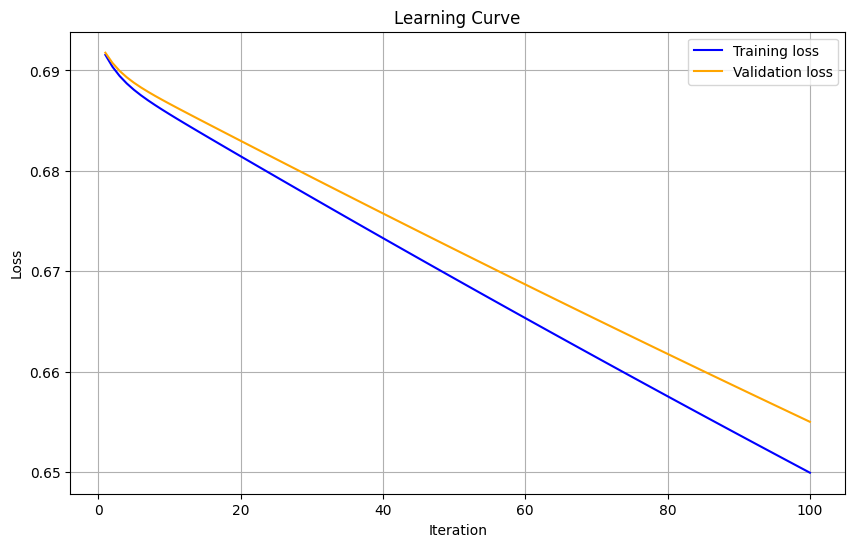

In [57]:
plt.figure(figsize=(10, 6))

iterations = np.arange(1, model.num_iter + 1)

plt.plot(
    iterations,
    model.loss,
    label="Training loss",
    color="blue"
)

plt.plot(
    iterations,
    model.val_loss,
    label="Validation loss",
    color="orange"
)

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Learning Curve")
plt.legend()
plt.grid(True)

plt.show()

### Interpretation

The training loss decreases progressively over the 100 iterations, which indicates that the model is learning from the training data. The validation loss also decreases and remains close to the training loss.

The validation loss is slightly higher than the training loss, which is expected because the model is optimized using the training data. Since the validation loss does not increase while the training loss continues to decrease, there is no clear sign of overfitting.

Overall, the model appears to learn progressively while maintaining good generalization performance.

In [ ]:
# Problem 7

In [59]:
# Sepal Width = column 1
# Petal Length = column 2

X_train_2d = X_train[:, [1, 2]]
X_val_2d = X_val[:, [1, 2]]

In [60]:
from sklearn.preprocessing import StandardScaler

scaler_2d = StandardScaler()

X_train_2d = scaler_2d.fit_transform(X_train_2d)
X_val_2d = scaler_2d.transform(X_val_2d)

In [8]:
model_2d = ScratchLogisticRegression(
    num_iter=100,
    lr=0.01,
    no_bias=False,
    verbose=False,
    lam=0.1
)

model_2d.fit(
    X_train_2d,
    y_train,
    X_val_2d,
    y_val
)

NameError: name 'X_train_2d' is not defined

In [62]:
import numpy as np

x_min = X[:, 1].min() - 0.5
x_max = X[:, 1].max() + 0.5

y_min = X[:, 2].min() - 0.5
y_max = X[:, 2].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid_original = np.c_[xx.ravel(), yy.ravel()]

In [63]:
grid_scaled = scaler_2d.transform(grid_original)

Z = model_2d.predict(grid_scaled)

Z = Z.reshape(xx.shape)

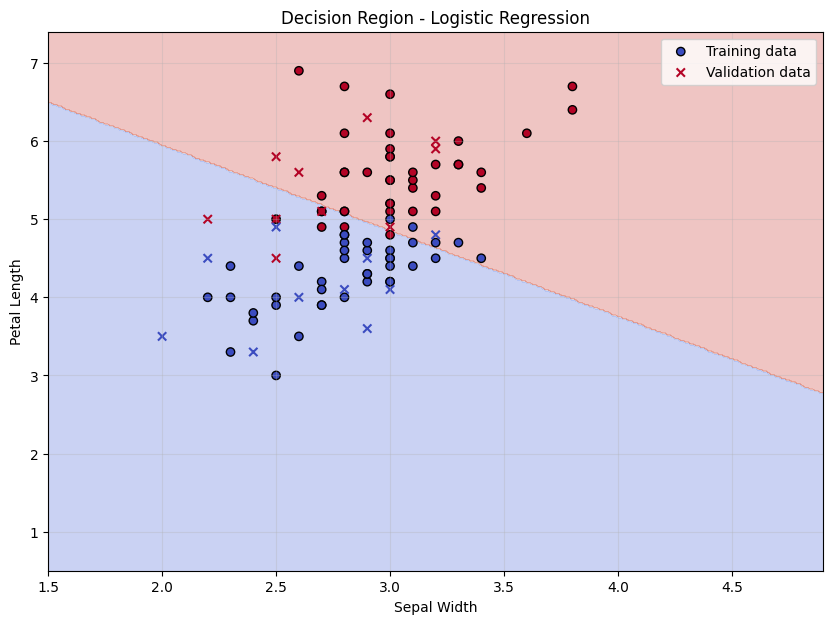

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.3,
    cmap=plt.cm.coolwarm
)

plt.scatter(
    X_train[:, 1],
    X_train[:, 2],
    c=y_train,
    cmap=plt.cm.coolwarm,
    edgecolor="black",
    label="Training data"
)

plt.scatter(
    X_val[:, 1],
    X_val[:, 2],
    c=y_val,
    cmap=plt.cm.coolwarm,
    marker="x",
    label="Validation data"
)

plt.xlabel("Sepal Width")
plt.ylabel("Petal Length")
plt.title("Decision Region - Logistic Regression")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

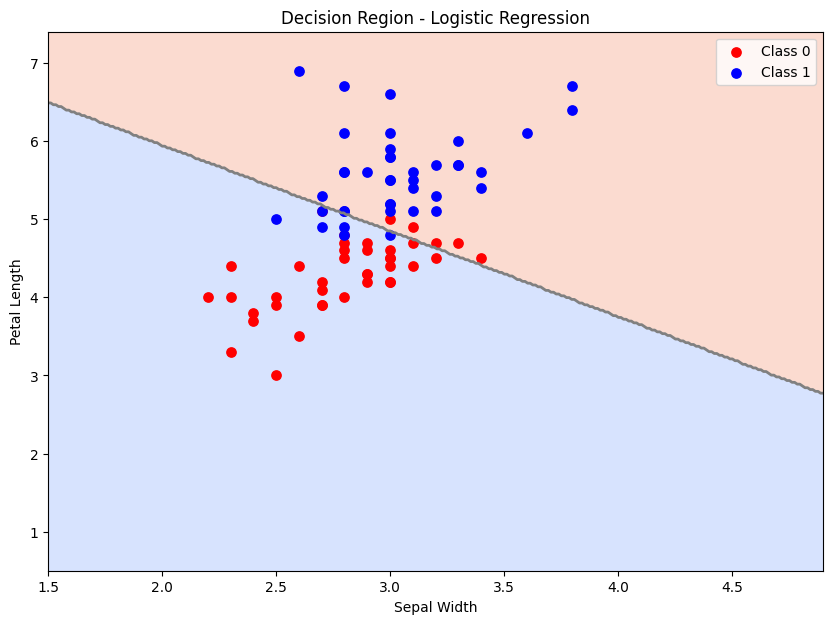

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

# Background decision regions
plt.contourf(
    xx,
    yy,
    Z,
    levels=[-0.5, 0.5, 1.5],
    alpha=0.35,
    cmap=plt.cm.coolwarm
)

# Decision boundary
plt.contour(
    xx,
    yy,
    Z,
    levels=[0.5],
    colors="gray",
    linewidths=2
)

# Class 0
plt.scatter(
    X_train[y_train == 0, 1],
    X_train[y_train == 0, 2],
    color="red",
    s=45,
    label="Class 0"
)

# Class 1
plt.scatter(
    X_train[y_train == 1, 1],
    X_train[y_train == 1, 2],
    color="blue",
    s=45,
    label="Class 1"
)

plt.xlabel("Sepal Width")
plt.ylabel("Petal Length")
plt.title("Decision Region - Logistic Regression")

plt.legend()
plt.grid(False)

plt.show()

In [ ]:
# Problem 7

In [11]:
print(ScratchLogisticRegression)

<class '__main__.ScratchLogisticRegression'>


In [12]:
print(model_2d)

In [13]:
print(model_2d.theta)

None


In [14]:
model_2d = ScratchLogisticRegression(
    num_iter=100,
    lr=0.01,
    no_bias=False,
    verbose=False,
    lam=0.1
)

In [19]:
[name for name, value in globals().items()
 if isinstance(value, ScratchLogisticRegression)]

['model_2d', 'model']

In [20]:
print("model theta:", model.theta)
print("model_2d theta:", model_2d.theta)

model theta: None
model_2d theta: None


In [23]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

# Keep only versicolor (1) and virginica (2)
mask = (y == 1) | (y == 2)

X = X[mask]
y = y[mask]

# Convert labels:
# versicolor = 0
# virginica = 1
y = (y == 2).astype(int)

# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Standardize using training data only
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (80, 4)
X_val: (20, 4)
y_train: (80,)
y_val: (20,)


In [24]:
model = ScratchLogisticRegression(
    num_iter=100,
    lr=0.01,
    no_bias=False,
    verbose=False,
    lam=0.1
)

model.fit(
    X_train,
    y_train,
    X_val,
    y_val
)

print("theta:", model.theta)

theta: [4.03649399e-05 1.67289227e-01 1.09737700e-01 2.83332493e-01
 3.20304149e-01]


In [25]:
y_pred_original = model.predict(X_val)

print("Original predictions:")
print(y_pred_original)

Original predictions:
[1 1 0 0 0 0 1 1 0 0 0 1 0 0 0 1 0 0 0 0]


In [26]:
import pickle

# Save only parameters and metadata needed for prediction
model_data = {
    "theta": model.theta,
    "no_bias": model.no_bias
}

with open("logistic_model.pkl", "wb") as f:
    pickle.dump(model_data, f)

print("Model saved with pickle.")

Model saved with pickle.


In [27]:
with open("logistic_model.pkl", "rb") as f:
    loaded_data = pickle.load(f)

loaded_model = ScratchLogisticRegression(
    num_iter=100,
    lr=0.01,
    no_bias=loaded_data["no_bias"],
    verbose=False,
    lam=0.1
)

# Restore learned parameters
loaded_model.theta = loaded_data["theta"]

y_pred_loaded = loaded_model.predict(X_val)

print(
    "Pickle predictions identical:",
    np.array_equal(y_pred_original, y_pred_loaded)
)

Pickle predictions identical: True


In [28]:
import numpy as np

np.savez(
    "logistic_model.npz",
    theta=model.theta,
    no_bias=model.no_bias
)

print("Model saved with np.savez.")

Model saved with np.savez.


In [29]:
loaded_data_npz = np.load("logistic_model.npz")

loaded_model_npz = ScratchLogisticRegression(
    num_iter=100,
    lr=0.01,
    no_bias=bool(loaded_data_npz["no_bias"]),
    verbose=False,
    lam=0.1
)

# Restore learned parameters
loaded_model_npz.theta = loaded_data_npz["theta"]

print("Model loaded with np.savez.")

Model loaded with np.savez.


In [30]:
y_pred_npz = loaded_model_npz.predict(X_val)

print(
    "NPZ predictions identical:",
    np.array_equal(y_pred_original, y_pred_npz)
)

NPZ predictions identical: True
